### **TRABAJO PRÁCTICO N° 2: Redes Convolucionales, Detección de Objetos y Redes Recurrentes - Problema 1**
---
 1er cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
| Martinez Dufour, Caterina | M-7169/2   |
| Grimaldi, Damián Daniel   | G-5977/3   |
| Tapia, Fabrizio           | T-3095/3   |

**Docentes:** *Salvañá, Leandro* - *Fernández, Florencia*

### 1. Descripción del dataset
---

En este trabajo, nuestro objetivo es construir, entrenar y optimizar una red neuronal convolucional desde cero para clasificar imágenes de razas de perros.

#### Librerias

In [56]:
# Librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import optuna
from sklearn.metrics import recall_score
import time

In [57]:
import gdown
import zipfile
import os
import random, numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset


In [58]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Carga del dataset
---

In [59]:
!pip install gdown


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# ID de tu archivo de Drive
file_id = '1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = 'dataset_perros.zip' 

# Descargar el archivo
gdown.download(url, archivo_descargado, quiet=False)
# Descomprimir el archivo en la carpeta
carpeta_destino = 'problema_1/dataset_problema1'

# Creamos la carpeta si no existe
if not os.path.exists(carpeta_destino):
    os.makedirs(carpeta_destino)

# Extraemos el contenido
try:
    with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino)
    # Eliminar el archivo .zip descargado
    os.remove(archivo_descargado) 
    
except zipfile.BadZipFile:
    print("Error.")

Downloading...
From (original): https://drive.google.com/uc?id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu
From (redirected): https://drive.google.com/uc?id=1aw3nX2c3Nk8EURGKV7hzTZJd-OaVuzmu&confirm=t&uuid=1aadb888-419e-4266-b330-58be27eda092
To: c:\Users\Usuario\cnn-rnn-objectdetection-deeplearning\problema_1\dataset_perros.zip
100%|██████████| 226M/226M [00:37<00:00, 6.01MB/s] 


### 3. Preparación de datos
---

El dataset descargado está dividido en conjuntos de entrenamiento, validación y prueba, cada uno organizado en su respectiva carpeta. A continuación, visualizaremos los datos de entrenamiento y realizaremos el preprocesamiento de las imágenes:

In [61]:
# Definir rutas principales
DATASET_DIR = 'problema_1/dataset_problema1'
CSV_PATH = os.path.join(DATASET_DIR, 'dogs.csv')

df_dogs = pd.read_csv(CSV_PATH)
print("Información del Dataset (dogs.csv):")
print(f"Total de registros anotados: {len(df_dogs)}")

Información del Dataset (dogs.csv):
Total de registros anotados: 9346


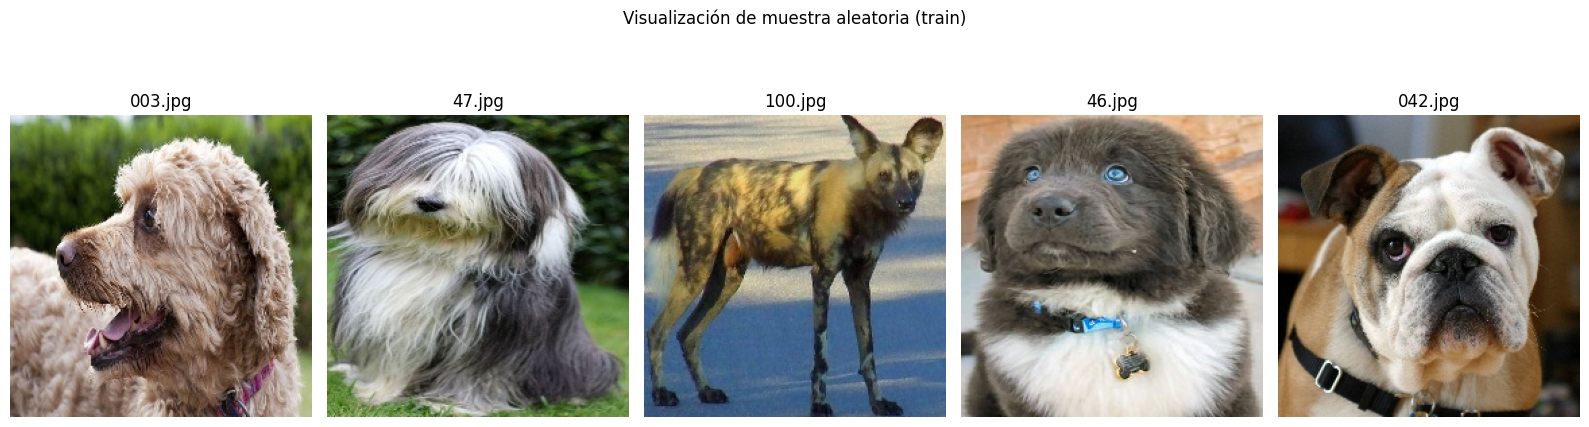

In [62]:
# ruta de dataset de entrenamiento
path_train = os.path.join(DATASET_DIR, 'train')

# lista de las imágenes de entrenamiento
imagenes_train = []
for root, dirs, files in os.walk(path_train):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            imagenes_train.append(os.path.join(root, file))

# Seleccionar 5 imágenes al azar
muestra_fotos = random.sample(imagenes_train, min(5, len(imagenes_train)))
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle('Visualización de muestra aleatoria (train)')

for i, img_path in enumerate(muestra_fotos):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(img_path))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

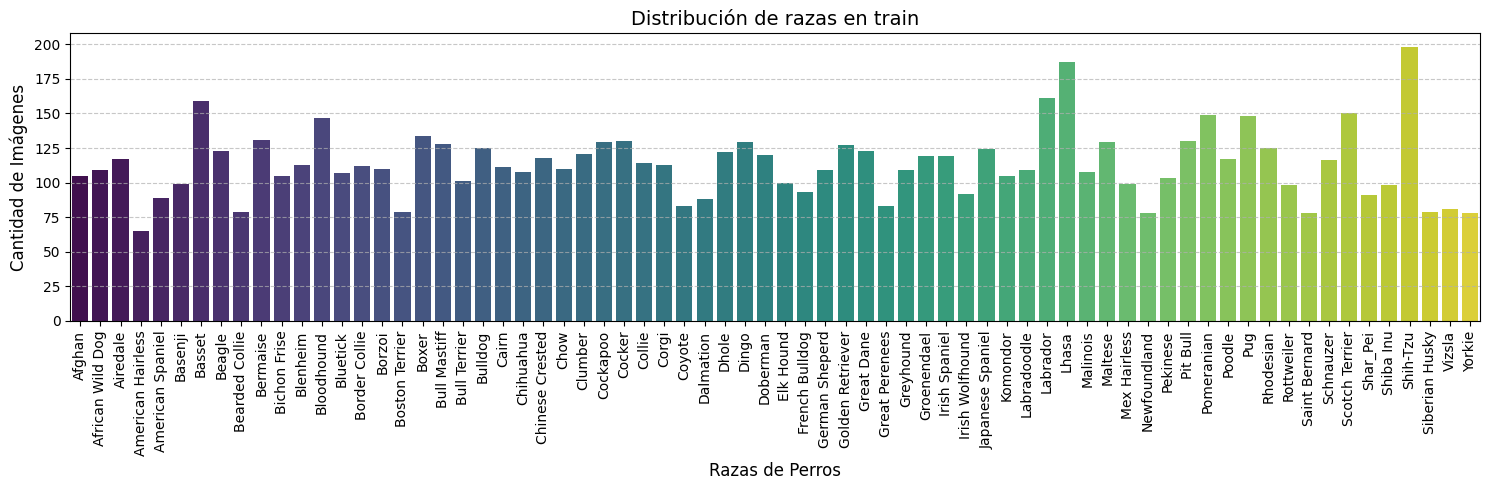

In [63]:
# Extraer el nombre de la raza
razas_train = [os.path.basename(os.path.dirname(p)) for p in imagenes_train]
# Contar cuántas imágenes hay por cada raza
conteo_clases = Counter(razas_train)

plt.figure(figsize=(15, 5))
sns.countplot(x=razas_train, hue=razas_train, palette="viridis", legend=False)
plt.title('Distribución de razas en train', fontsize=14)
plt.xlabel('Razas de Perros', fontsize=12)
plt.ylabel('Cantidad de Imágenes', fontsize=12)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Al analizar el histograma, observamos un gran desbalance en la cantidad de imágenes, con un rango que oscila entre aproximadamente 65 y 200 imágenes por cada una de las 70 razas de perro. Para evitar que el modelo tenga un sesgo (bias) hacia las clases con más muestras, decidimos normalizar el dataset bajo los siguientes criterios:
- Submuestreo (undersampling): Se limitó a un máximo de 100 imágenes por raza de para mantener un dataset equilibrado y optimizar los tiempos de procesamiento.
- Sobremuestreo sintético: Aquellas razas de perro que tenga menor cantidad de imagenes pasara por un proceso de aumento de datos (data augmentation) para balancear el dataset.

In [64]:
transform_sin_augmentation_train = transforms.Compose([
    # Redimensionar la imagen en 224 x 224
    transforms.Resize((224, 224)),                         
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),                                 
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_con_augmentation_train = transforms.Compose([
    transforms.Resize((224, 224)),                          # Redimensionar la imagen en 224 x 224
    transforms.RandomHorizontalFlip(p=0.5),                 # Volteo espejo horizontal
    transforms.RandomRotation(degrees=15),                  # Rotación leve
    transforms.ColorJitter(brightness=0.2, contrast=0.2),   # Brillo y contraste

    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### 4. Experimentos
---

Dentro de cada experimento tambi ́en pueden variar hiperpar ́ametros como learning rate, batch size, n ́umero de  ́epocas y optimizador

#### E1 — Línea base

CNN simple: 3 bloques Conv-BN-ReLU-MaxPool + cabeza clasificadora densa.

In [65]:
class CNN_LineaBase(nn.Module):
    """
    CNN para clasificación multiclase (razas de perros). 
    Cada bloque = 3 convoluciones + pooling.
    - Primer conv: detecta patrones locales en la entrada del bloque.
    - Segundo y tercer conv: combina esos patrones en representaciones más complejas.
    - MaxPool: comprime la resolución espacial a la mitad, incrementa el campo receptivo efectivo de las capas siguientes.

    Arquitectura: tres bloques convolucionales (Conv-BN-ReLU-MaxPool) + clasificador denso.
    """
    
    def __init__(self, num_clases, dropout_rate=0.5):
        """
        num_clases: Número total de razas de perros en el dataset.
        dropout_rate=0.5: fracción de neuronas desactivadas en cada forward pass durante el entrenamiento. 0.5 = 50%.
        """
        super().__init__() # llama al constructor de la clase padre nn.Module.

        # BLOQUE CONVOLUCIONAL 1
        # Entrada: (batch, 3, 224, 224)
        # Salida:  (batch, 32, 112, 112), reducción por el MaxPool
        self.bloque1 = nn.Sequential(
            # kernel: cada filtro es una matriz 3×3 = 9 pesos.
            # padding: agrega 1 fila/columna de ceros en cada borde.
            # bias=False: no se aprende un bias por neurona en esta capa.
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),                                     # normalización de batch para feature maps de 32 canales.
            nn.ReLU(inplace=True),                                  # inplace=True: modifica el tensor en el lugar sin crear una copia.
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # kernel_size=2: ventana 2×2 píxeles. stride=2: el paso entre posiciones de la ventana es 2.
        )

        # BLOQUE CONVOLUCIONAL 2
        # Entrada: (batch, 32, 112, 112)
        # Salida:  (batch, 64, 56, 56), reducción por el MaxPool
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # BLOQUE CONVOLUCIONAL 3
        # Entrada: (batch, 64, 56, 56)
        # Salida:  (batch, 128, 28, 28), reducción por el MaxPool
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False), 
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # CLASIFICADOR DENSO
        # Convierte los feature maps en una predicción escalar (logit).
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            # Aplicamos Flatten, el vector resultante tendrá: 128 * 28 * 28 = 100.352 elementos
            nn.Linear(128 * 28 * 28, 256), 
            # ReLU después de la capa densa: introduce no-linealidad.
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, num_clases),
        )

        self._init_pesos()              # Inicializar los pesos de todas las capas.

    def _init_pesos(self):
        """
        Inicializa los pesos de todas las capas del modelo.

        self.modules(): iterador recursivo que devuelve TODOS los submódulos
        del modelo, incluyendo los anidados dentro de nn.Sequential.

        isinstance(m, nn.Conv2d): True solo si m es una capa Conv2d.
        Usamos isinstance en vez de type(m) == nn.Conv2d para ser correcto
        con herencia: si algún submódulo hereda de Conv2d, también aplica.
        """
        for m in self.modules():
            # Inicialización Kaiming Normal (He initialization) para Conv2d
            if isinstance(m, nn.Conv2d):
                # mode='fan_out': usa el número de conexiones de SALIDA para calcular la varianza
                # nonlinearity='relu': ajusta la constante de escala para ReLU.
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                # BatchNorm2d tiene dos parámetros aprendibles: γ (weight) y β (bias)
                nn.init.ones_(m.weight)         # γ ← 1 para todos los canales (estandar)
                nn.init.zeros_(m.bias)          # β ← 0 para todos los canales (estandar)
            elif isinstance(m, nn.Linear):
                # El bias de Linear lo inicializamos en cero
                # El entrenamiento lo ajustará al valor que necesite
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        Define el flujo de datos a través de la red.
        PyTorch llama a este método automáticamente cuando hacemos modelo(x).

        x: tensor de entrada con forma (batch_size, 3, 224, 224).
        """
        x = self.bloque1(x)             # extrae patrones simples, reduce resolución
        x = self.bloque2(x)             # combina patrones, reduce más
        x = self.bloque3(x)             # representaciones de alto nivel
        x = self.clasificador(x)        # aplana y clasifica
        return x

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE = device 

print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


Dado que el entrenamiento puede ser costoso en cómputo, se recomienda trabajar con un subconjunto de 5 a 10 razas elegidas. (elegi trabajar con 10 por ahora)

In [67]:
train_dataset = ImageFolder(root='problema_1/dataset_problema1/train', transform=transform_sin_augmentation_train)
valid_dataset = ImageFolder(root='problema_1/dataset_problema1/valid', transform=transform_sin_augmentation_train)
test_dataset  = ImageFolder(root='problema_1/dataset_problema1/test',  transform=transform_sin_augmentation_train)

NUM_RAZAS = 10
razas_seleccionadas = train_dataset.classes[:NUM_RAZAS]
print(f"Razas seleccionadas: {razas_seleccionadas}\n")

# Buscar los índices de las imágenes que pertenecen a esas 10 razas
# Filtramos basándonos en que la etiqueta sea menor a 10 (0, 1, 2..., 9)
indices_train = [i for i, (_, label) in enumerate(train_dataset) if label < NUM_RAZAS]
indices_valid = [i for i, (_, label) in enumerate(valid_dataset) if label < NUM_RAZAS]
indices_test  = [i for i, (_, label) in enumerate(test_dataset) if label < NUM_RAZAS]

# Crear los subconjuntos recortados
train_dataset = Subset(train_dataset, indices_train)
valid_dataset = Subset(valid_dataset, indices_valid)
test_dataset  = Subset(test_dataset, indices_test)

# Crear los DataLoaders con los datasets ya recortados
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Imágenes de entrenamiento resultantes: {len(train_dataset)}")
print(f"Imágenes de validación resultantes: {len(valid_dataset)}")
print(f"Imágenes de test resultantes: {len(test_dataset)}")

Razas seleccionadas: ['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise']

Imágenes de entrenamiento resultantes: 1076
Imágenes de validación resultantes: 100
Imágenes de test resultantes: 100


In [68]:
NUM_RAZAS = 10
# Crear el modelo
model_e1 = CNN_LineaBase(num_clases=NUM_RAZAS, dropout_rate=0.5)

# Mover el modelo a la GPU o CPU según corresponda
model_e1 = model_e1.to(DEVICE)

print(f"\n Arquitectura CNN Línea Base E1 (PyTorch):")
print(model_e1)

# Calcular parámetros numéricos
total_p = sum(p.numel() for p in model_e1.parameters())
train_p = sum(p.numel() for p in model_e1.parameters() if p.requires_grad)
print(f"\n   Total parámetros:       {total_p:,}")
print(f"   Parámetros entrenables: {train_p:,}")
print(f"   (Son iguales porque no hemos congelado ninguna capa)")

# Verificar dimensiones con un batch de prueba (4 imágenes a 224x224)
with torch.no_grad():
    x_prueba = torch.randn(4, 3, 224, 224).to(DEVICE)
    print(f"\n Verificación de dimensiones con batch de prueba (4 imágenes):")
    print(f"   Entrada:  {list(x_prueba.shape)}")

    # Pasar por cada bloque individualmente para verificar las dimensiones reales
    x1 = model_e1.bloque1(x_prueba)
    x2 = model_e1.bloque2(x1)
    x3 = model_e1.bloque3(x2)
    salida = model_e1(x_prueba)

    print(f"   → bloque1: {list(x1.shape)}  (32 canales, resolución reducida 224→112)")
    print(f"   → bloque2: {list(x2.shape)}  (64 canales, resolución reducida 112→56)")
    print(f"   → bloque3: {list(x3.shape)}  (128 canales, resolución reducida 56→28)")
    print(f"   → flatten: [{x3.shape[0]}, {128*28*28}]  (128×28×28={128*28*28} valores por imagen)")
    print(f"   → salida:  {list(salida.shape)}  ({NUM_RAZAS} logits de salida, uno por raza de perro)")


 Arquitectura CNN Línea Base E1 (PyTorch):
CNN_LineaBase(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(in

In [69]:
def loop_entrenamiento_cnn(modelo, loader_train, loader_val, criterio, optimizador, scheduler,
                            epochs=50, patience=10, device=DEVICE, nombre='CNN'):
    """
    Loop de entrenamiento genérico para CNNs en PyTorch.
    Reutilizable para clasificación binaria y multiclase.

    Parámetros:
        modelo:       instancia de nn.Module ya creada y movida al dispositivo.
        loader_train: DataLoader con el conjunto de entrenamiento.
        loader_val:   DataLoader con el conjunto de validación.
        criterio:     función de pérdida (BCEWithLogitsLoss o CrossEntropyLoss).
        optimizador:  algoritmo de optimización (Adam, SGD, etc.).
        scheduler:    ajustador de learning rate (ReduceLROnPlateau).
        epochs:       número máximo de épocas a entrenar.
        patience:     épocas sin mejora en val_loss antes de hacer early stopping.
        device:       dispositivo donde están el modelo y los datos.
        nombre:       string para identificar el modelo en los mensajes.
    """

    # historial: diccionario donde guardamos las métricas de cada época.
    historial = {
        'train_loss': [],   # pérdida promedio en el training set por época
        'val_loss':   [],   # pérdida promedio en el validation set por época
        'train_acc':  [],   # accuracy en training por época
        'val_acc':    [],   # accuracy en validation por época
    }

    # mejor_val_loss: la menor pérdida de validación vista hasta ahora.
    mejor_val_loss = float('inf')

    # mejor_pesos: copia del state_dict del modelo en el momento de menor val_loss.
    # state_dict es un diccionario {nombre_capa: tensor_de_pesos}.
    mejor_pesos = None

    # espera: contador de épocas consecutivas sin mejora en val_loss.
    # Cuando llega a 'patience', se activa el early stopping.
    espera = 0

    print(f"\n Entrenando {nombre} | epochs={epochs} | patience={patience}")
    print(f"   {'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Train Acc':>10} | {'Val Acc':>9} | {'LR':>8}")
    print("   " + "─"*62)

    for epoca in range(1, epochs + 1):

        # ════════════════════════════════════════════════════════
        #  FASE DE ENTRENAMIENTO
        # ════════════════════════════════════════════════════════

        # modelo.train(): pone el modelo en modo entrenamiento.
        # Activa dos comportamientos que son distintos en training vs inferencia:
        #   1. Dropout: apaga neuronas aleatoriamente (en eval lo desactiva).
        #   2. BatchNorm: usa estadísticas del batch actual Y actualiza running_mean y running_var (en eval usa solo los acumulados).
        modelo.train()

        # Acumuladores para calcular el promedio al final de la época.
        train_loss_total = 0.0   # suma de (loss × tamaño_batch) de todos los batches
        train_correctos  = 0     # total de predicciones correctas en la época
        train_total      = 0     # total de ejemplos procesados en la época

        for X_batch, y_batch in loader_train:
            # loader_train es un iterador: en cada iteración devuelve un par
            # (X_batch, y_batch) donde:
            #   X_batch: tensor de imágenes, forma (batch_size, 3, 32, 32)
            #   y_batch: tensor de etiquetas, forma (batch_size,)

            # .to(device): mueve X_batch e y_batch al mismo dispositivo que el modelo.
            # Si el modelo está en GPU y los datos en CPU, PyTorch da error.
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Conversión de tipo para BCEWithLogitsLoss:
            # Los DataLoaders de torchvision devuelven etiquetas como torch.int64 (long).
            # BCEWithLogitsLoss requiere float32 porque opera con probabilidades continuas.
            # CrossEntropyLoss sí acepta long, por eso solo convertimos para BCE.
            if isinstance(criterio, nn.BCEWithLogitsLoss):
                # .float(): convierte de int64 a float32.
                # {0, 1} enteros → {0.0, 1.0} flotantes.
                y_batch = y_batch.float()

            # ── FORWARD PASS ────────────────────────────────────
            # logits: tensor de forma (batch_size,) para binaria o (batch_size, N) para multiclase.
            # No tienen activación: son números reales arbitrarios en (-∞, +∞).
            logits = modelo(X_batch)

            # criterio(logits, y_batch): calcula la pérdida del batch.
            # Para BCEWithLogitsLoss: aplica Sigmoid a los logits y calcula BCE.
            # Para CrossEntropyLoss: aplica Softmax a los logits y calcula CCE.
            # loss es un escalar (tensor de forma ()).
            loss = criterio(logits, y_batch)

            # ── BACKWARD PASS ───────────────────────────────────
            # optimizador.zero_grad(): limpia los gradientes acumulados del paso anterior.
            # PyTorch acumula gradientes por defecto (diseñado para RNNs/TBPTT).
            optimizador.zero_grad()

            # loss.backward(): calcula ∂L/∂w para TODOS los parámetros del modelo.
            # Recorre el grafo computacional hacia atrás (output → input) aplicando la Regla de la Cadena. Al terminar, cada parámetro p tiene p.grad = ∂L/∂p.
            loss.backward()

            # Gradient clipping: limita la norma euclidiana del gradiente total.
            # clip_grad_norm_(parámetros, max_norm=1.0):
            #   Calcula la norma del gradiente: ||∇|| = √(Σ (∂L/∂w_i)²)
            #   Si ||∇|| > max_norm: escala todos los gradientes por max_norm/||∇||
            #   Si ||∇|| ≤ max_norm: no hace nada.
            # max_norm=1.0: si la norma del gradiente supera 1.0, se recorta.
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)

            # optimizador.step(): actualiza los pesos usando los gradientes calculados.
            optimizador.step()

            # Acumular pérdida ponderada por el tamaño del batch.
            # loss.item(): extrae el valor escalar del tensor (Python float).
            train_loss_total += loss.item() * X_batch.size(0)

            # Calcular predicciones y contar aciertos del batch.
            if isinstance(criterio, nn.MSELoss):
                pass   # no hay accuracy en regresión
            elif isinstance(criterio, nn.BCEWithLogitsLoss):
                preds = (torch.sigmoid(logits) > 0.5).long()
                train_correctos += (preds == y_batch.long()).sum().item()
            else:
                preds = logits.argmax(dim=1)
                train_correctos += (preds == y_batch).sum().item()

            train_total += X_batch.size(0)

        train_loss = train_loss_total / train_total
        train_acc  = train_correctos  / train_total

        # ════════════════════════════════════════════════════════
        #  FASE DE VALIDACIÓN (sin actualizar pesos)
        # ════════════════════════════════════════════════════════

        # modelo.eval(): pone el modelo en modo inferencia.
        # Desactiva Dropout: todas las neuronas activas, predicciones determinísticas.
        # BatchNorm: usa running_mean y running_var acumulados, no las del batch actual.
        modelo.eval()
        val_loss_total = 0.0
        val_correctos  = 0
        val_total      = 0

        # torch.no_grad(): bloque de contexto que desactiva el cálculo del grafo.
        with torch.no_grad():
            for X_val, y_val in loader_val:
                X_val = X_val.to(device)
                y_val = y_val.to(device)
                logits_v = modelo(X_val)
                if isinstance(criterio, nn.MSELoss):
                    loss_v = criterio(logits_v, y_val)
                elif isinstance(criterio, nn.BCEWithLogitsLoss):
                    y_val_f = y_val.float()
                    loss_v  = criterio(logits_v, y_val_f)
                    preds_v = (torch.sigmoid(logits_v) > 0.5).long()
                    val_correctos += (preds_v == y_val).sum().item()
                else:
                    loss_v  = criterio(logits_v, y_val)
                    preds_v = logits_v.argmax(dim=1)
                    val_correctos += (preds_v == y_val).sum().item()
                # Estas dos líneas estaban faltando:
                val_loss_total += loss_v.item() * X_val.size(0)
                val_total      += X_val.size(0)

        val_loss = val_loss_total / val_total
        val_acc  = val_correctos  / val_total

        # Guardar métricas de esta época en el historial
        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['train_acc'].append(train_acc)
        historial['val_acc'].append(val_acc)

        # ── SCHEDULER ───────────────────────────────────────────
        # optimizador.param_groups[0]['lr']: extrae el learning rate actual.
        # param_groups es una lista de diccionarios, uno por grupo de parámetros.
        # Con un solo grupo (el default), el índice [0] es el único grupo.
        # Guardamos el lr ANTES de llamar scheduler.step() porque el scheduler
        # puede modificarlo, y queremos imprimir el lr que se usó en esta época.
        lr_actual = optimizador.param_groups[0]['lr']

        # scheduler.step(val_loss): informa al scheduler la pérdida de validación.
        # ReduceLROnPlateau compara val_loss con su mejor valor histórico:
        #   Si no mejoró durante 'patience' épocas → lr ← lr × factor (0.5).
        #   Si mejoró → reinicia el contador.
        # Esto hace que el learning rate baje cuando el entrenamiento se estanca,
        # permitiendo una búsqueda más fina en la vecindad del mínimo actual.
        scheduler.step(val_loss)

        # ── EARLY STOPPING ──────────────────────────────────────
        if val_loss < mejor_val_loss:
            # Nueva mejor val_loss: guardar el estado actual del modelo.
            mejor_val_loss = val_loss
            # modelo.state_dict(): diccionario {nombre_parámetro: tensor_de_pesos}.
            # Contiene TODOS los parámetros y buffers (running_mean de BatchNorm, etc.).
            # {k: v.clone()}: hacemos una COPIA PROFUNDA de cada tensor.
            # Sin .clone(), el diccionario guardaría referencias a los mismos tensores
            # en memoria, que seguirán cambiando en las épocas siguientes.
            # Con .clone(), guardamos el estado exacto de este momento.
            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            espera = 0   # reiniciar contador de épocas sin mejora
        else:
            espera += 1  # una época más sin mejorar

        # Imprimir progreso cada 5 épocas o cuando hay una mejora (espera==0)
        if epoca % 5 == 0 or espera == 0:
            if isinstance(criterio, nn.MSELoss):
                print(f"   {epoca:6d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                      f"  RMSE val={val_loss**0.5:.4f} | {lr_actual:.2e}")
            else:
                print(f"   {epoca:6d} | {train_loss:10.4f} | {val_loss:10.4f} | "
                      f"{train_acc:10.4f} | {val_acc:9.4f} | {lr_actual:.2e}")

        # Condición de parada anticipada
        if espera >= patience:
            print(f"\n Early stopping en época {epoca} "
                  f"(mejor val_loss: {mejor_val_loss:.4f})")
            break

    # Restaurar los pesos del mejor momento del entrenamiento.
    # load_state_dict(mejor_pesos): carga el diccionario guardado en el modelo.
    # strict=True (default): los nombres de las capas deben coincidir exactamente.
    if mejor_pesos:
        modelo.load_state_dict(mejor_pesos)
        print(f"Mejores pesos restaurados (época con menor val_loss)")

    return historial

In [70]:
import torch.nn as nn
import torch.optim as optim

# 1. Creamos el modelo E1 (10 clases, dropout 0.5)
model_e1 = CNN_LineaBase(num_clases=10, dropout_rate=0.5).to(DEVICE)

# 2. Configuramos su optimizador y su scheduler obligatorio
criterion = nn.CrossEntropyLoss()
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.001)
scheduler_e1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer_e1, mode='min', factor=0.5, patience=3)

# LLAMAMOS A LA FUNCIÓN GENÉRICA Y GUARDAMOS EL HISTORIAL EN 'historial_e1'
historial_e1 = loop_entrenamiento_cnn(
    modelo=model_e1,
    loader_train=train_loader,
    loader_val=valid_loader,
    criterio=criterion,
    optimizador=optimizer_e1,
    scheduler=scheduler_e1,
    epochs=15,             # Las 15 épocas que definimos para la línea base
    patience=5,            # Si pasa 5 épocas sin mejorar el loss de val, frena solo
    device=DEVICE,
    nombre='E1_LineaBase'
)


 Entrenando E1_LineaBase | epochs=15 | patience=5
    Época | Train Loss |   Val Loss |  Train Acc |   Val Acc |       LR
   ──────────────────────────────────────────────────────────────
        1 |    30.5261 |     8.8075 |     0.1441 |    0.0700 | 1.00e-03
        2 |     2.3166 |     2.3029 |     0.1580 |    0.1000 | 1.00e-03
        5 |     2.2905 |     2.3047 |     0.1478 |    0.1000 | 1.00e-03

 Early stopping en época 7 (mejor val_loss: 2.3029)
Mejores pesos restaurados (época con menor val_loss)


#### E2 — Arquitectura más profunda

Aumentar profundidad. Explorar el efecto de agregar más capas convolucionales y variar el tama ̃no de los filtros (3×3 vs 5×5) y los strides.

In [71]:
# Completar

#### E3 — Bloques avanzados

Incorporar al menos uno de los siguientes: bloques residuales (skipconnections estilo ResNet), m ́odulos Inception (ramas paralelas con filtros de distinto tama ̃no y convoluciones 1×1 como cuello de botella)

In [72]:
# Completar

#### E4 — Regularización y Data Augmentation

Agregar Dropout, BatchNormalization si no estaba, y un pipeline de Data Augmentation (flips horizontales, rotaciones, variaciones de brillo/contraste, recortes aleatorios, etc.).

In [73]:
# Completar

### 5. Reporte comparativo de cada experimento
---

In [74]:
# Generamos la tabla comparativa de los experimentos
datos_tabla = {
    'Experimento': ['E1', 'E2', 'E3', 'E4'],
    'Acc. Train': [None, None, None, None],
    'Acc. Val': [None, None, None, None],
    'Acc. Test': [None, None, None, None],
    'Parámetros': [None, None, None, None],
    'Épocas': [None, None, None, None],
    'Observaciones': ['', '', '', '']
}

# Creamos el DataFrame
df_experimentos = pd.DataFrame(datos_tabla)

In [75]:
df_experimentos

,Experimento,Acc. Train,Acc. Val,Acc. Test,Parámetros,Épocas,Observaciones
0,E1,None,None,None,None,None,
1,E2,None,None,None,None,None,
2,E3,None,None,None,None,None,
3,E4,None,None,None,None,None,


Para el mejor modelo obtenido realizar:
- Curvas de loss y accuracy (train vs. validación) por ́epoca.
- Matriz de confusión en el conjunto de test.
- Al menos 5 ejemplos de predicciones correctas e incorrectas con la imagen, la clase real y la clase predicha.
- Análisis breve: ¿qué razas se confunden más entre sí? ¿Por qué?

### 6. Conclusión
---

Completar